In [11]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from build_dataset import build_dataset
from itertools import product

%load_ext autoreload
%autoreload 2
%matplotlib inline


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
words_corpus = open("names.txt", "r").read().splitlines()
words_corpus[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [13]:
chars_corpus = sorted(list(set(''.join(words_corpus)))) #Set so it doesnt repeat the words
print(f"This are the words in the corpus{chars_corpus} and the len {len(chars_corpus)}")

This are the words in the corpus['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z'] and the len 26


#### Build the vocabulary of characters and mapping to/from integers

In [14]:
chars_corpus = sorted(list(set(''.join(words_corpus)))) #Set so it doesnt repeat the words
print(f"This are the words in the corpus{chars_corpus} and the len {len(chars_corpus)}")

This are the words in the corpus['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z'] and the len 26


In [15]:
stoi = {letter:index+1 for index, letter in enumerate(chars_corpus)} #This for making the letters and the index
stoi['.'] = 0 #Its the first index its going to be .
print(stoi)

{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}


In [16]:
itos = {index:letter for letter,index in stoi.items()}
print(len(itos))

27


#### Build the Dataset

In [17]:
import random
block_size_context = 8  #the context length: how many characters 
                        # the model sees to predict the next one
                        # e.g. "_ _ _ -> ?"


random.seed(42) #This is for reproducibility
random.shuffle(words_corpus)
n1 = int(0.80 * len(words_corpus)) #This is for the training set
n2 = int(0.90 * len(words_corpus)) #This is for the validation set and the test set

X_training, Y_training = build_dataset(words_corpus=words_corpus[:n1],block_size=block_size_context, stoi=stoi) #until 80%
X_validation, Y_validation = build_dataset(words_corpus=words_corpus[n1:n2], block_size=block_size_context, stoi=stoi) #10 for validation
X_test, Y_test = build_dataset(words_corpus=words_corpus[n2:], block_size=block_size_context, stoi=stoi)#10 for test

torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])


In [18]:
import torch.nn.init as init
from mlp_torch import Sequential, Embedding, FlattenConsecutive, Linear, BatchNorm1D, Tanh

#MLP revisited hyper parameters
# hierarchical network
n_embd = 24 # the dimensionality of the character embedding vectors
n_hidden = 128 # the number of neurons in the hidden layer of the MLP
batch_size = 32
lenght_characters_dataset = len(itos)
generator = torch.Generator().manual_seed(2147483647)


In [19]:
model = Sequential([
    Embedding(num_embeddings=lenght_characters_dataset, embedding_dim=n_embd),
    FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, generator=generator, bias=False), BatchNorm1D(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, generator=generator, bias=False), BatchNorm1D(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, generator=generator, bias=False), BatchNorm1D(n_hidden), Tanh(),
    Linear(n_hidden, lenght_characters_dataset, generator=generator)
])

#Paramter init
# parameter init
with torch.no_grad():
  model.layers[-1].weight *= 0.1 # last layer make less confident

parameters = model.parameters()
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True


76579


In [ ]:
#Same optimization as the last time

max_steps = 200000 #This are the epochs
lossi = []
for i in range(max_steps):
    
    #The minibatch construct
    ix = torch.randint(0, X_training.shape[0], (batch_size, ))
    Xb, Yb = X_training[ix], Y_training[ix] #Batch X, Y
    
    #Forward pass
    logits = model(Xb) #the prediction of the model with the training sample
    loss = F.cross_entropy(logits, Yb) #The loss fuction of the model and compared between the logits and the label
    
    #Backward pass 
    for p in parameters:
        p.grad = None
    
    loss.backward()
    
    #Update: Simple SGD
    lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad
     # track stats
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    

      0/ 200000: 3.2359
  10000/ 200000: 2.1864
  20000/ 200000: 1.4923
  30000/ 200000: 1.9705
  40000/ 200000: 1.9828
  50000/ 200000: 2.3502
  60000/ 200000: 2.0331
  70000/ 200000: 1.8076
  80000/ 200000: 2.0811
  90000/ 200000: 1.9858
 100000/ 200000: 2.0633
 110000/ 200000: 1.8337
 120000/ 200000: 2.0099
 130000/ 200000: 2.0231
 140000/ 200000: 2.2974
 150000/ 200000: 1.9854
 160000/ 200000: 2.2033
 170000/ 200000: 1.8090
 180000/ 200000: 2.3947
 190000/ 200000: 1.8206


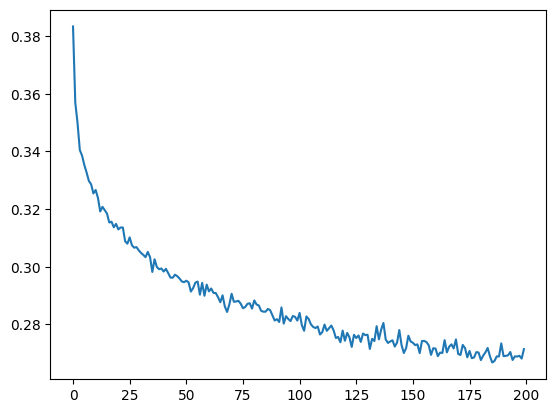

In [22]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [23]:
# put layers into eval mode (needed for batchnorm especially)
for layer in model.layers:
  layer.training = False

In [24]:
# evaluate the loss
@torch.no_grad() # this decorator disables gradient tracking inside pytorch
def split_loss(split):
  x,y = {
    'train': (X_training, Y_training),
    'val': (X_validation, Y_validation),
    'test': (X_test, Y_test),
  }[split]
  logits = model(x)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.8256449699401855
val 2.0423829555511475


In [26]:
# sample from the model
for _ in range(20):
    
    out = []
    context = [0] * block_size_context # initialize with all ...
    while True:
      # forward pass the neural net
      logits = model(torch.tensor([context]))
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out)) # decode and print the generated

eniashawa.
aevena.
joshtan.
lovin.
casofin.
lowyn.
miasus.
kemario.
aneliegh.
azriel.
avalis.
dak.
ashis.
halesi.
calven.
etzi.
ryven.
amyiah.
malonia.
kyrim.
